# Расследование II-02 · Пассажиры после факта

**Бюро аналитических расследований, 7–8 апреля 2026 года.** После первого заключения Антон Карев приносит новый пример «Компаса»: прогноз выживания пассажиров «Титаника» с почти идеальной метрикой.

Тимур Сафин, хранитель данных Бюро, передаёт замороженный снимок и его контрольную сумму. Вера Орлова задаёт вопрос до запуска модели: **какие сведения существовали в момент, когда решение ещё можно было принять?** Ответ превращает обычную работу с пропусками в аудит временной доступности.

**Цель:** построить воспроизводимый конвейер предобработки и количественно показать, как `boat` и `body` превращают описание последствия в ложный «прогноз».


## Маршрут семинара

Работаем повторяющимся циклом: формулируем проверяемый вопрос, запускаем один небольшой этап, читаем наблюдаемый вывод и только затем переходим дальше.

1. **Источник:** сверить SHA-256, форму `1309 × 14` и первые строки.
2. **Схема и пропуски:** получить таблицу `поле → тип, число и доля пропусков, уникальные значения`, затем прочитать диаграмму.
3. **Временная доступность:** для каждого поля записать момент появления; отдельно проверить `boat` и `body`.
4. **Разбиение:** один раз зафиксировать общие train/test-индексы и сравнить доли классов.
5. **Честный конвейер:** определить семь доступных признаков и обучить все преобразования только через `Pipeline`.
6. **Ориентир и основная модель:** одинаково вычислить accuracy и ROC AUC для `DummyClassifier` и логистической регрессии.
7. **Контролируемый антипример:** на тех же строках добавить post-outcome поля и измерить скачок, не выдавая этот вариант за внедряемый.
8. **Ошибки и записка:** найти группы с высокой описательной долей ошибок, учесть размер групп и отделить факт от интерпретации.

Ориентир — 4–5 часов. Тетрадь автономна и не загружает данные во время локального анализа.


In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "learner"
CASE_SLUG = "case-02"
ARCHIVE_NAME = "part-2-case-02.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").exists()
            and (candidate / f"{CASE_SLUG}.ipynb").exists()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-02
RANDOM_STATE = 42


In [2]:
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Замороженный источник

В расследовании лежит CSV-представление OpenML dataset 40945, version 1. До чтения проверяем локальный SHA-256, затем ожидаем таблицу из 1 309 строк и 14 столбцов с бинарной целью `survived`.

Контрольная сумма не доказывает историческую истинность записей. Она подтверждает более узкое свойство: все участники анализируют одинаковые байты. `data/SOURCE.md` и `data/LICENSE.txt` фиксируют происхождение и лицензионную метку OpenML.


In [3]:
DATASET_SHA256 = "c617db2c7470716250f6f001be51304c76bcc8815527ab8bae734bdca0735737"
data_path = DATA_DIR / "titanic.csv"
actual_sha256 = sha256_file(data_path)
if actual_sha256 != DATASET_SHA256:
    raise RuntimeError("Контрольная сумма titanic.csv не совпала")

passengers = pd.read_csv(data_path, na_values=["?"])
passengers["survived"] = passengers["survived"].astype(int)
print(f"SHA-256: {actual_sha256}")
print("Форма:", passengers.shape)
display(passengers.head(3))


SHA-256: c617db2c7470716250f6f001be51304c76bcc8815527ab8bae734bdca0735737
Форма: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Что подтвердил источник

Совпавший SHA-256 связывает дальнейшие выводы с зафиксированным CSV. Форма `(1309, 14)` подтверждает ожидаемый снимок, а первые три строки показывают единицу наблюдения: одна строка описывает одного пассажира. Значение `survived` уже приведено к целому классу `0` или `1`.

Мы получили воспроизводимую таблицу и проверили её размер. Чтобы решить, какие столбцы требуют обработки и смыслового аудита, теперь построим сводку схемы и пропусков.

## 2. Тип — ещё не смысл

`object` сообщает только способ хранения. Оно не говорит, является ли поле категорией, свободным текстом, идентификатором или информацией из будущего. Поэтому технический аудит дополняем смысловым.


In [4]:
# Каждая строка schema_audit описывает один исходный столбец.
schema_audit = pd.DataFrame(
    {
        "dtype": passengers.dtypes.astype(str),
        "missing_n": passengers.isna().sum(),
        "missing_share": passengers.isna().mean(),
        "unique": passengers.nunique(dropna=True),
    }
).sort_values("missing_share", ascending=False)
numeric_ranges = passengers.select_dtypes(include="number").agg(["min", "max"]).T
duplicate_count = int(passengers.duplicated().sum())
target_audit = (
    passengers["survived"]
    .value_counts()
    .sort_index()
    .rename(index={0: "did_not_survive", 1: "survived"})
    .rename("count")
    .to_frame()
    .assign(share=lambda table: table["count"] / len(passengers))
)

display(schema_audit.round(3))
display(numeric_ranges)
print("Полных дубликатов строк:", duplicate_count)
display(target_audit.round(3))


,dtype,missing_n,missing_share,unique
body,float64,1188,0.908,121
cabin,str,1014,0.775,186
boat,str,823,0.629,27
home.dest,str,564,0.431,369
age,float64,263,0.201,98
embarked,str,2,0.002,3
fare,float64,1,0.001,281
pclass,int64,0,0.000,3
survived,int64,0,0.000,2
name,str,0,0.000,1307


,min,max
pclass,1.0000,3.0000
survived,0.0000,1.0000
age,0.1667,80.0000
sibsp,0.0000,8.0000
parch,0.0000,9.0000
fare,0.0000,512.3292
body,1.0000,328.0000


Полных дубликатов строк: 0


,count,share
survived,,
did_not_survive,809,0.618
survived,500,0.382


### Интерпретация связи post-outcome полей с целью

В строках `did_not_survive` и `survived` доли заполненности `boat` и `body` резко различаются. Это наблюдаемая связь с уже наступившим исходом и практическое объяснение, почему импьютер и индикатор пропуска способны извлечь утечку. Таблица не говорит, что лодка «вызывает» выживание, и не устанавливает действия конкретного человека.

Мы подтвердили временную недоступность и связь наличия значений с целью. Чтобы сравнение моделей отвечало одному вопросу, теперь зафиксируем единую внешнюю тестовую выборку.

## 4. Внешняя тестовая выборка

Индексы фиксируем до предобработки. Параметры заполнения, набор категорий и коэффициенты должны определяться только по обучающей выборке. `Pipeline` обеспечивает это технически, а корректное разбиение — методологически.


In [5]:
# Модели с утечкой и без неё используем с одинаковыми train_index и test_index.
train_index, test_index = train_test_split(
    passengers.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=passengers["survived"],
)
train_data = passengers.loc[train_index].copy()
test_data = passengers.loc[test_index].copy()
y_train = train_data["survived"]
y_test = test_data["survived"]

split_balance = pd.DataFrame(
    {"train": y_train.value_counts(normalize=True), "test": y_test.value_counts(normalize=True)}
).rename(index={0: "did_not_survive", 1: "survived"})
display(split_balance.round(3))
print("train:", len(train_data), "| test:", len(test_data))


,train,test
survived,,
did_not_survive,0.618,0.619
survived,0.382,0.381


train: 981 | test: 328


### Что подтвердили audit и разбиение

`schema_audit` фиксирует типы, уникальные значения и пропуски, `numeric_ranges` — наблюдаемые числовые границы, а отдельная строка сообщает число полных дубликатов. `target_audit` показывает исходный баланс цели до подготовки. После этого `train_data` и `test_data` получают разные исходные индексы; `split_balance` подтверждает близкие доли классов благодаря `stratify`.

Внешний test теперь заморожен. До единой итоговой ячейки мы обучаем преобразования и фиксируем три сценария только на `train_data`; test не используется для выбора признаков, параметров или порога. Сначала завершим описательный аудит пропусков исходного snapshot.


### Где сосредоточены пропуски

Следующая ячейка получает уже вычисленную `schema_audit` и строит горизонтальные столбцы только для полей с пропусками. Длина столбца — доля отсутствующих значений от 1 309 строк. График нужен, чтобы увидеть масштаб неполноты до решения о временной доступности и способе импутации.


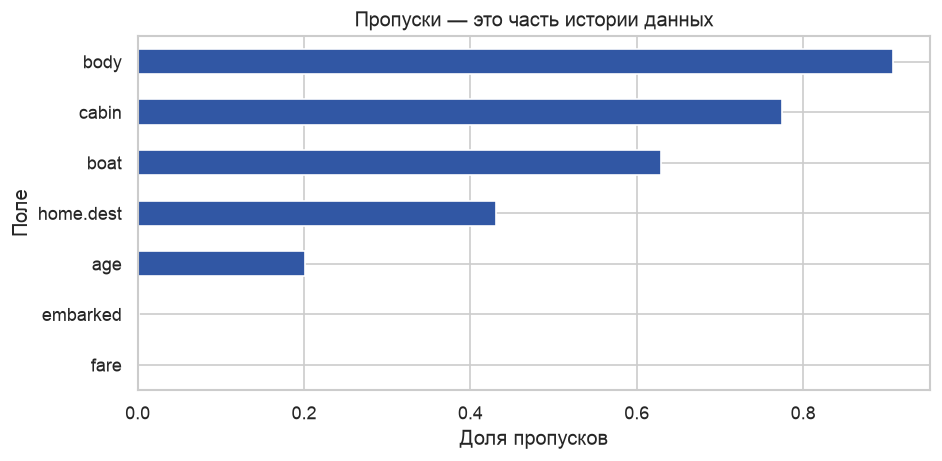

In [6]:
missing_plot = schema_audit.query("missing_n > 0").sort_values("missing_share")
ax = missing_plot["missing_share"].plot.barh(figsize=(8, 4), color="#3157a4")
ax.set(xlabel="Доля пропусков", ylabel="Поле", title="Пропуски — это часть истории данных")
plt.tight_layout()

# Явно кодируем PNG, чтобы nbclient сохранил график даже с невизуальным backend Agg.
missing_png = BytesIO()
ax.figure.savefig(missing_png, format="png", bbox_inches="tight", dpi=120)
plt.close(ax.figure)
display(Image(data=missing_png.getvalue()))


### Что показал график пропусков

Самые неполные поля — `body`, `cabin` и `boat`; у `age` отсутствует примерно пятая часть значений, тогда как `fare` и `embarked` пропущены редко. Сам по себе пропуск не определяет допустимость признака: для этого нужен момент его появления. Поэтому следующий этап строит карту временной доступности, а позднее медианы и категории обучаются только на train внутри `Pipeline`.


### Интерпретация схемы и пропусков

`schema_audit` имеет одну строку на поле. `missing_n` — абсолютное число отсутствующих значений, `missing_share` — доля от 1 309 строк, а `unique` не считает пропуски. Диаграмма показывает, что особенно разрежены `body`, `cabin` и `boat`; отсутствие значения здесь нельзя автоматически считать случайным.

Самая важная граница: высокая доля пропусков не делает поле бесполезным, а низкая не делает его допустимым. Мы проверили техническую неполноту столбцов. Для выбора признаков требуется момент их появления, поэтому переходим к карте доступности.

## 3. Карта доступности

Момент решения фиксируем так: модель должна работать **до того, как известен исход эвакуации**. Для каждого поля назначаем один статус:

- `available` — могло быть известно в момент решения;
- `post_outcome` — появилось после исхода;
- `excluded_identifier` — идентификатор или свободный текст, который не используется в базовой модели;
- `target` — то, что предсказываем.

Причина записана человеческим предложением, а не выведена из типа pandas.


In [7]:
# Поле можно использовать, только если его значение известно в момент прогноза.
availability_rows = [
    ("pclass", "available", "класс билета известен до исхода"),
    ("survived", "target", "факт выживания — предсказываемый исход"),
    ("name", "excluded_identifier", "прямой идентификатор и свободный текст"),
    ("sex", "available", "записан до исхода"),
    ("age", "available", "мог быть известен до исхода"),
    ("sibsp", "available", "состав семьи в манифесте"),
    ("parch", "available", "состав семьи в манифесте"),
    ("ticket", "excluded_identifier", "высокая кардинальность; не нужен baseline"),
    ("fare", "available", "стоимость билета известна заранее"),
    ("cabin", "excluded_identifier", "разреженный код; исключён из baseline"),
    ("embarked", "available", "порт посадки известен заранее"),
    ("boat", "post_outcome", "номер шлюпки фиксирует результат эвакуации"),
    ("body", "post_outcome", "номер найденного тела появляется после гибели"),
    ("home.dest", "excluded_identifier", "свободный текст высокой кардинальности"),
]
field_audit = pd.DataFrame(
    availability_rows, columns=["feature", "decision_status", "reason"]
)
display(field_audit)


,feature,decision_status,reason
0,pclass,available,класс билета известен до исхода
1,survived,target,факт выживания — предсказываемый исход
2,name,excluded_identifier,прямой идентификатор и свободный текст
3,sex,available,записан до исхода
4,age,available,мог быть известен до исхода
5,sibsp,available,состав семьи в манифесте
6,parch,available,состав семьи в манифесте
7,ticket,excluded_identifier,высокая кардинальность; не нужен baseline
8,fare,available,стоимость билета известна заранее
9,cabin,excluded_identifier,разреженный код; исключён из baseline


### Что установила карта доступности

Таблица отделяет семь заранее доступных признаков от цели, идентификаторов и сведений после исхода. `boat` и `body` получили статус `post_outcome`: их нельзя подавать модели, которая должна сработать до завершения эвакуации.

### Пропуск как сигнал из будущего

У `boat` значение обычно есть у спасённых, у `body` — у части погибших. Даже само наличие значения может кодировать исход. Проверим это группировкой `survived → доля заполненных boat/body, число строк`; таблица описывает связь, но не доказывает причинность.


In [8]:
leak_evidence = pd.DataFrame(
    {
        "boat_present": passengers.groupby("survived")["boat"].apply(lambda s: s.notna().mean()),
        "body_present": passengers.groupby("survived")["body"].apply(lambda s: s.notna().mean()),
        "count": passengers.groupby("survived").size(),
    }
).rename(index={0: "did_not_survive", 1: "survived"})
display(leak_evidence.round(3))


,boat_present,body_present,count
survived,,,
did_not_survive,0.011,0.15,809
survived,0.954,0.00,500


### Фиксируем допустимый набор признаков

Карта доступности установила семь полей, известных до исхода, и два post-outcome поля. Следующая ячейка создаёт только обучающую матрицу честного сценария и два явных списка признаков. Ожидаемый результат — семь названий без `boat` и `body`; внешний test остаётся нераскрытым.


In [9]:
# honest_features содержит только признаки, доступные в момент прогноза.
honest_numeric = ["age", "sibsp", "parch", "fare"]
honest_categorical = ["pclass", "sex", "embarked"]
honest_features = honest_numeric + honest_categorical
post_outcome_features = ["boat", "body"]

X_train_honest = train_data[honest_features]
print("Честные признаки:", honest_features)


Честные признаки: ['age', 'sibsp', 'parch', 'fare', 'pclass', 'sex', 'embarked']


`X_train_honest` имеет семь столбцов в зафиксированном порядке. `boat` и `body` остаются в отдельном списке `post_outcome_features`, поэтому их отсутствие в честном наборе проверяется явно. Тестовые признаки пока не извлекаются. Следующий шаг создаёт фабрику конвейеров, чтобы импутация, масштабирование, кодирование и логистическая регрессия обучались одним вызовом `.fit()` только на train.


In [10]:
def build_logistic_pipeline(
    numeric_features: list[str], categorical_features: list[str]
) -> Pipeline:
    numeric_steps = Pipeline(
        [
            # add_indicator=True добавляет признаки, отмечающие исходные пропуски.
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_steps = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            # handle_unknown='ignore' кодирует новую категорию нулями вместо ошибки.
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessing = ColumnTransformer(
        [
            ("numeric", numeric_steps, numeric_features),
            ("categorical", categorical_steps, categorical_features),
        ]
    )
    # Импутация, кодирование и масштабирование обучаются внутри `Pipeline` только на обучающей выборке.
    return Pipeline(
        [
            ("preprocess", preprocessing),
            (
                "model",
                LogisticRegression(
                    solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
                ),
            ),
        ]
    )


### Как устроен объект модели

`honest_features` содержит четыре числовых и три категориальных поля — всего семь заранее доступных признаков. Функция `build_logistic_pipeline` возвращает один `Pipeline`: внутри него `preprocess` создаёт числовую матрицу признаков, а `model` обучается на этой матрице. Такой объект можно обучать и применять целиком, не заполняя пропуски вручную.

### Метрики и базовая модель

Сначала определим направление метрик. **Accuracy** — доля правильных классов; больше означает больше правильных ответов, но при балансе около 62/38 значение около 0,62 можно получить, всегда выбирая большинство.

**ROC AUC** — вероятность того, что модель поставит случайно выбранному выжившему более высокий score, чем случайно выбранному невыжившему. Метрика оценивает ранжирование по всем порогам: `0.5` соответствует случайному ранжированию, `1.0` — идеальному; больше лучше. Это не доля правильных ответов и не гарантия калибровки вероятностей.

`DummyClassifier(strategy="most_frequent")` служит нижним ориентиром. Его accuracy и ROC AUC вычислим теми же функциями, что и для основной модели.


In [11]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train_honest, y_train)
dummy_class = int(dummy.classes_[np.argmax(dummy.class_prior_)])
print(
    "Dummy зафиксирован без открытия test: "
    f"постоянный класс={dummy_class}, доля в train={dummy.class_prior_.max():.3f}"
)


Dummy зафиксирован без открытия test: постоянный класс=0, доля в train=0.618


### Что зафиксировал baseline

Dummy выучил по `y_train` только самый частый класс; показанная доля относится к train и ещё не является внешней метрикой. Правило baseline зафиксировано без просмотра test. Теперь тем же способом зафиксируем честный `Pipeline`, не вычисляя на test ни прогнозов, ни метрик.


In [12]:
honest_model = build_logistic_pipeline(honest_numeric, honest_categorical)
honest_model.fit(X_train_honest, y_train)
print(
    "Честная модель зафиксирована на train:",
    honest_model.named_steps["model"].get_params()["solver"],
    "| признаков до преобразования:",
    len(honest_features),
)


Честная модель зафиксирована на train: liblinear | признаков до преобразования: 7


### Что зафиксировано до внешней оценки

Честный сценарий использует семь заранее доступных полей, а импьютер, scaler, one-hot encoder и коэффициенты обучены только на train. Архитектура и стандартный порог `0.5` уже определены. Для контролируемого отрицательного примера осталось заранее зафиксировать отдельный конвейер с `boat` и `body`; только после этого один блок откроет test для всех трёх сценариев.


### Интерпретация Dummy и честной модели

Dummy показывает, сколько accuracy даёт один только наиболее частый класс; его постоянный score приводит к ROC AUC `0.5`. Честная логистическая регрессия должна превзойти этот ориентир и по доле правильных ответов, и по качеству ранжирования. ROC AUC честной модели описывает различимость классов на зафиксированном тесте, но не превращает score в точную вероятность и не доказывает готовность к внедрению.

Мы получили честный ориентир на семи доступных признаках. Чтобы измерить вред неверной постановки, теперь создадим контролируемый антипример на тех же train/test-строках.

## 6. Контролируемый эксперимент с утечкой

Намеренно добавляем `boat` как категорию и `body` как число. Это **не кандидат для внедрения**, а отрицательный контроль: он показывает размер и направление ошибки постановки.

Отдельная категория `__MISSING__` особенно важна: отсутствие номера лодки или тела само связано с тем, что произошло после катастрофы.


In [13]:
leaky_numeric = honest_numeric + ["body"]
leaky_categorical = honest_categorical + ["boat"]
leaky_features = leaky_numeric + leaky_categorical

# Этот вариант намеренно нарушает временную границу и нужен только для измерения утечки.
leaky_model = build_logistic_pipeline(leaky_numeric, leaky_categorical)
leaky_model.fit(train_data[leaky_features], y_train)
print("Антипример зафиксирован на train; post-outcome поля:", ["boat", "body"])


Антипример зафиксирован на train; post-outcome поля: ['boat', 'body']


### Единственное открытие внешнего test

Baseline, честный конвейер, антипример с утечкой и порог классификации уже зафиксированы по train. Следующая ячейка впервые получает тестовые признаки, строит прогнозы всех трёх сценариев и одинаково вычисляет accuracy и ROC AUC. Компактная таблица позволяет сравнивать строки на одной границе данных.


In [14]:
# Тестовые матрицы создаются впервые после фиксации всех трёх сценариев.
X_test_honest = test_data[honest_features]
dummy_predictions = dummy.predict(X_test_honest)
dummy_probabilities = dummy.predict_proba(X_test_honest)[:, 1]
honest_predictions = honest_model.predict(X_test_honest)
honest_probabilities = honest_model.predict_proba(X_test_honest)[:, 1]
leaky_predictions = leaky_model.predict(test_data[leaky_features])
leaky_probabilities = leaky_model.predict_proba(test_data[leaky_features])[:, 1]

dummy_accuracy = accuracy_score(y_test, dummy_predictions)
dummy_auc = roc_auc_score(y_test, dummy_probabilities)
honest_accuracy = accuracy_score(y_test, honest_predictions)
honest_auc = roc_auc_score(y_test, honest_probabilities)
leaky_accuracy = accuracy_score(y_test, leaky_predictions)
leaky_auc = roc_auc_score(y_test, leaky_probabilities)

comparison = pd.DataFrame(
    [
        {"scenario": "dummy", "accuracy": dummy_accuracy, "roc_auc": dummy_auc, "deployable": False},
        {"scenario": "honest", "accuracy": honest_accuracy, "roc_auc": honest_auc, "deployable": "needs validation"},
        {"scenario": "post-outcome leak", "accuracy": leaky_accuracy, "roc_auc": leaky_auc, "deployable": False},
    ]
)
display(comparison.round(3))


,scenario,accuracy,roc_auc,deployable
0,dummy,0.619,0.500,False
1,honest,0.805,0.867,needs validation
2,post-outcome leak,0.966,0.991,False


### Интерпретация контролируемого антипримера

Строка `post-outcome leak` резко превосходит `honest`, потому что `boat`, `body` и их пропуски описывают уже известный результат. Одинаковое разбиение делает разность метрик сопоставимой, но не делает утекший сценарий честным: train и test содержат один и тот же механизм кодирования будущего.

Следующая завершённая формулировка связывает скачок с моментом доступности, а не с «умом» алгоритма.


In [15]:
leak_explanation = (
    "boat и body создаются после исхода; наличие и значение этих полей прямо кодируют "
    "результат. Случайный split помещает одинаковый механизм кодирования и в train, и "
    "в test, поэтому метрика выглядит честной технически, но отвечает на неверный вопрос."
)
print(leak_explanation)


boat и body создаются после исхода; наличие и значение этих полей прямо кодируют результат. Случайный split помещает одинаковый механизм кодирования и в train, и в test, поэтому метрика выглядит честной технически, но отвечает на неверный вопрос.


## 7. Ошибки корректной модели

Для каждой тестовой строки сохраняем истинный класс, прогноз, score и индикатор ошибки. Затем группируем по `sex × pclass`: `n` — размер подгруппы, `errors` — число ошибок, `error_rate` — их доля. Чем выше `error_rate`, тем хуже модель классифицировала именно эту тестовую подгруппу; у малых `n` доля нестабильна.

Таблица нужна не для поиска «виноватых пассажиров», а для описания систематических режимов ошибки. Порог не меняем и причинных выводов из группировки не делаем.


In [16]:
honest_error_table = test_data[["pclass", "sex", "age", "fare", "survived"]].copy()
honest_error_table["predicted"] = honest_predictions
honest_error_table["probability"] = honest_probabilities
honest_error_table["error"] = honest_error_table["survived"] != honest_error_table["predicted"]

error_summary = (
    honest_error_table.groupby(["sex", "pclass"], dropna=False)
    .agg(n=("error", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
    .sort_values("error_rate", ascending=False)
)
display(error_summary.round(3))

# Первая строка превращает отсортированную сводку в буквальное наблюдение с размером группы.
top_group = error_summary.reset_index().iloc[0]
print(
    "Наблюдаемый режим с наибольшей долей ошибок: "
    f"sex={top_group['sex']}, pclass={top_group['pclass']}; "
    f"n={int(top_group['n'])}, errors={int(top_group['errors'])}, "
    f"error_rate={top_group['error_rate']:.3f}."
)


n  errors  error_rate
sex    pclass                         
female 3        53      26       0.491
male   1        43      17       0.395
       2        42       5       0.119
       3       122      14       0.115
female 1        40       2       0.050
       2        28       0       0.000

Наблюдаемый режим с наибольшей долей ошибок: sex=female, pclass=3; n=53, errors=26, error_rate=0.491.


### Как читать таблицу ошибок

Первая строка после сортировки — наблюдаемая группа с самой высокой долей ошибок; столбцы `n` и `errors` показывают, сколькими тестовыми пассажирами подтверждается эта доля. Сравнивать только `error_rate` опасно: одна ошибка в маленькой группе может выглядеть хуже нескольких ошибок в большой. Это описательная диагностика одного holdout, а не доказательство различий в населении или причинного влияния пола и класса.

Мы нашли конкретный режим ошибки и одновременно увидели ограничение размера подгрупп. Для окончательного вывода теперь отделим установленную утечку от более широких утверждений.

> **Типичная ошибка:** удалить столбец только потому, что у него много пропусков, или оставить его только потому, что конвейер умеет заполнять пропуски. Сначала выясняем происхождение и время появления поля; потом выбираем техническую обработку.

**Дополнительное исследование:** сравните распределения `fare` в обучающей и тестовой выборках. Это полезная диагностика, но не используйте тестовую выборку для подбора правил обработки.


## 8. Аудиторская записка

Записка сводит этапы в проверяемую цепочку: одинаковый snapshot → карта доступности → единый split → честный `Pipeline` → контролируемый антипример → таблица ошибок. Установленный факт ссылается на конкретные поля и измеренное сравнение; интерпретация не приписывает человеку намерение, которого данные не показывают.


In [17]:
audit_memo = {
    "established_fact": (
        f"boat и body появляются после исхода; с ними ROC AUC растёт с "
        f"{honest_auc:.3f} до {leaky_auc:.3f}."
    ),
    "supported_interpretation": (
        "Почти идеальная метрика поставщика зависит от post-outcome leakage и не "
        "оценивает прогноз в заявленный момент решения."
    ),
    "not_proven": (
        "Снимок и ноутбук не устанавливают, кто добавил поля и был ли скачок намеренным."
    ),
    "limitations": (
        "Исторический датасет неполон; честная модель ещё не проверена для современной "
        "операционной задачи и не является политикой спасения."
    ),
    "recommended_action": (
        "Исключить post-outcome поля, зафиксировать паспорт доступности признаков и "
        "пересчитать метрики по заранее утверждённому протоколу."
    ),
}
display(pd.Series(audit_memo, name="Записка II-02").to_frame())


,Записка II-02
established_fact,boat и body появляются после исхода; с ними RO...
supported_interpretation,Почти идеальная метрика поставщика зависит от ...
not_proven,"Снимок и ноутбук не устанавливают, кто добавил..."
limitations,Исторический датасет неполон; честная модель е...
recommended_action,"Исключить post-outcome поля, зафиксировать пас..."


### Интерпретация записки

Высокая метрика реальна для переданной таблицы, но нерелевантна заявленному будущему решению: post-outcome поля превращают прогнозирование в распознавание уже известного исхода. Корректный `Pipeline` устраняет эту конкретную утечку процедуры, однако одна внешняя выборка и исторический snapshot ещё не подтверждают современную операционную пригодность модели.


In [18]:
fitted_numeric_pipeline = honest_model.named_steps["preprocess"].named_transformers_[
    "numeric"
]
fitted_numeric_imputer = fitted_numeric_pipeline.named_steps["imputer"]
fitted_numeric_scaler = fitted_numeric_pipeline.named_steps["scaler"]

expected_train_medians = X_train_honest[honest_numeric].median().to_numpy()
imputed_train_numeric = fitted_numeric_imputer.transform(
    X_train_honest[honest_numeric]
)
imputed_all_numeric = fitted_numeric_imputer.transform(
    passengers[honest_numeric]
)
numeric_preprocessing_fit_on_train_only = (
    np.allclose(fitted_numeric_imputer.statistics_, expected_train_medians)
    and np.allclose(
        fitted_numeric_scaler.mean_, imputed_train_numeric.mean(axis=0)
    )
    and not np.allclose(
        fitted_numeric_scaler.mean_, imputed_all_numeric.mean(axis=0)
    )
)

checks = {
    "snapshot_shape": passengers.shape == (1309, 14),
    "split_disjoint": set(train_index).isdisjoint(test_index),
    "honest_fields_exclude_future": set(post_outcome_features).isdisjoint(honest_features),
    "pipeline_beats_dummy": honest_accuracy > dummy_accuracy,
    "dummy_auc_computed_as_05": np.isclose(dummy_auc, 0.5),
    "honest_auc_in_broad_range": 0.80 < honest_auc < 0.92,
    "leaky_auc_above_098": 0.98 < leaky_auc <= 1.0,
    "leak_creates_large_jump": leaky_auc - honest_auc > 0.10,
    "numeric_preprocessing_train_only": numeric_preprocessing_fit_on_train_only,
    "checksum_verified": actual_sha256 == DATASET_SHA256,
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
assert np.allclose(
    fitted_numeric_imputer.statistics_,
    X_train_honest[honest_numeric].median().to_numpy(),
)
assert np.allclose(
    fitted_numeric_scaler.mean_, imputed_train_numeric.mean(axis=0)
)
assert not np.allclose(
    fitted_numeric_scaler.mean_, imputed_all_numeric.mean(axis=0)
)
statuses = field_audit.set_index("feature")["decision_status"]
assert statuses["boat"] == statuses["body"] == "post_outcome"


,passed
snapshot_shape,True
split_disjoint,True
honest_fields_exclude_future,True
pipeline_beats_dummy,True
dummy_auc_computed_as_05,True
honest_auc_in_broad_range,True
leaky_auc_above_098,True
leak_creates_large_jump,True
numeric_preprocessing_train_only,True
checksum_verified,True


## Расследование закрыто

Перезапустите ядро, выполните **Run All** и сравните инварианты с `check_result.md`. В II-03 Бюро сохранит этот корректный конвейер, но спросит: одинаково ли полезны все правильные ответы и кому достаются ошибки?
